# From netCDF to numpy Array (MPI-ESM1-2-HR)
# SSP 245 (original)

## 1. Environment

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import calendar as cld
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

/Users/peyaudv/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
def get_slopes_and_pvalue(wp_meanseason):

    wp_meanseason_hist = wp_meanseason[:86,:,:,:]
#    wp_meanseason_fut = wp_meanseason[55:,:,:,:]
    
    origin_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    slope_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    pvalue_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    
#    origin_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    slope_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    pvalue_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    
    for i in range(wp_meanseason.shape[3]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanseason.shape[2]):
            for season in range(4):
                linregress_hist = linregress(np.arange(wp_meanseason_hist.shape[0]), wp_meanseason_hist[:,season,j,i])
                origin_hist[season][j][i] = linregress_hist.intercept
                slope_hist[season][j][i] = linregress_hist.slope
                pvalue_hist[season][j][i] = linregress_hist.pvalue
                
#                linregress_fut = linregress(np.arange(wp_meanseason_fut.shape[0]), wp_meanseason_fut[:,season,j,i])
#                origin_fut[season][j][i] = linregress_fut.intercept
#                slope_fut[season][j][i] = linregress_fut.slope
#                pvalue_fut[season][j][i] = linregress_fut.pvalue

#    return slope_hist, slope_fut, pvalue_hist, pvalue_fut
    return slope_hist, pvalue_hist

In [3]:
# Which Computer ?
#path_DIR = '/bettik/beaumetj/'  # On dahu
path_DIR = '/Users/peyaudv/Glaciers/MAR_GCMs/' # Local pc perso

In [4]:
# Where are the data files?
name_GCM = 'MPI-ESM1-2-HR'
#name_GCMlon = 'MPI-ESM1-2-LR'
dirGCM   = 'MPI-ESM1-2-HR'
dirMARGCM= 'MPI-ESM1-2-HR'
shortnameGCM= 'MPI-ESM'
realizati= 'r1i1p1f1'
#name_GCM = 'EC-Earth3' # seuls copie en local sur le MAC
#dirMARGCM= 'EC-Earth3'
#realizati= 'r25i1p1f1'


#scenario = 'SSP245' #'HIST' #'SSP245' #'SSP585' # MAR
scenario = 'ssp245' #'HIST' #'SSP245' #'SSP585' # GCM
#sim = 'EUy'
simHIST, simSSP = 'EUy', 'EUv'

path_MAR = path_DIR + 'MARout/'
path_MARSIMU= path_MAR+'/MAR-'+dirMARGCM+'/'

path_GCM= path_DIR+'GCM/'+dirGCM+'/'+scenario+'/'

data_freq = 'monthly'
data_freq_prefix = 'MON' # ICE for daily, MON for monthly

first_year = 2015
last_year =  2100

In [5]:
# define a function to compute seasonal mean
# Taking into account the differet number of days per months
def season_mean(dataset, calendar="standard"):
    # Make a DataArray with the number of days in each month, size = len(time)
    month_length = dataset.time.dt.days_in_month

    # Calculate the weights by grouping by 'time.season'
    weights = (
        month_length.groupby("time.season") / month_length.groupby("time.season").sum()
    )

    # Test that the sum of the weights for each season is 1.0
    np.testing.assert_allclose(weights.groupby("time.season").sum().values, np.ones(4))

    # Calculate the weighted average
    return (dataset * weights).groupby("time.season").sum(dim="time")

## 2. Save MPI

### 2.0 Open Dataset 

In [6]:
# Information on the first file
year=first_year
#file1=path_MAR+'/'+scenario+'/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_'+scenario+'.'+sim+'.TTz.'+str(year)+'.nc'

file1=path_GCM+'tas_Amon_'+name_GCM+'_'+scenario+'_'+realizati+'_gn_201501-210012.nc'#+str(year)+'01-'+str(2034)+'12.nc'
#file1='/bettik/peyaudv/MAR_GCMs/GCM/EC-Earth3/tas_Amon_EC-Earth3_ssp245_r1i1p1f1_gr_201501-201512_EU.nc '
print(file1)
dsGCM = xr.open_dataset(file1) # Alternative #ds = xr.open_dataset(os.path.join(path,file))
#ds

/Users/peyaudv/Glaciers/MAR_GCMs/GCM/MPI-ESM1-2-HR/ssp245/tas_Amon_MPI-ESM1-2-HR_ssp245_r1i1p1f1_gn_201501-210012.nc


In [7]:
dsGCM

<xarray.Dataset> Size: 304MB
Dimensions:    (time: 1032, bnds: 2, lat: 192, lon: 384)
Coordinates:
  * time       (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T1...
  * lat        (lat) float64 2kB -89.28 -88.36 -87.42 ... 87.42 88.36 89.28
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 17kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 6kB ...
    tas        (time, lat, lon) float32 304MB ...
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    contact:                cmip6-mpi-esm@dkrz.de
    ...                     ...
    variable_id:            tas
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by DKRZ is licensed und...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/5d919613-fddc-429a-a6eb-e7b4cb90eaeb
    NCO:                    netCDF Operators version 4.9.1 (Homepage = http:/...

In [8]:
# Domain
lon1=60;lon2=110;lat1=25;lat2=45    # Domain study: HMA
latS,latN,lonW,lonE = 42,49, 2,18   # Greater Alpine region 

imin = 4 ; imax = 18 # lon    (manually found)
jmin = 141 ; jmax = 148 # lat (manually found)
ni, nj = imax-imin, jmax-jmin
print("lon[imin],lon[imax] :",dsGCM.lon[imin].values,dsGCM.lon[imax].values)
print("lat[jmin],lat[jmax] :",dsGCM.lat[jmin].values,dsGCM.lat[jmax].values)
print("ni, nj :",ni, nj) 
longG=dsGCM.lon[imin:imax]
latiG=dsGCM.lat[jmin:jmax]

lon[imin],lon[imax] : 3.75 16.875
lat[jmin],lat[jmax] : 42.54527716699815 49.09068605129621
ni, nj : 14 7


In [9]:
# Color scale for the notebook
colo_scale = 'rainbow'
vmin_scale, vmax_scale = -5., 25. #-4, -3 #6, 10 #

Text(0.5, 1.0, 'Mean Temperature (tas_Amon_MPI-ESM1-2-HR_ssp245_r1i1p1f1_gn_201501-210012.nc)')

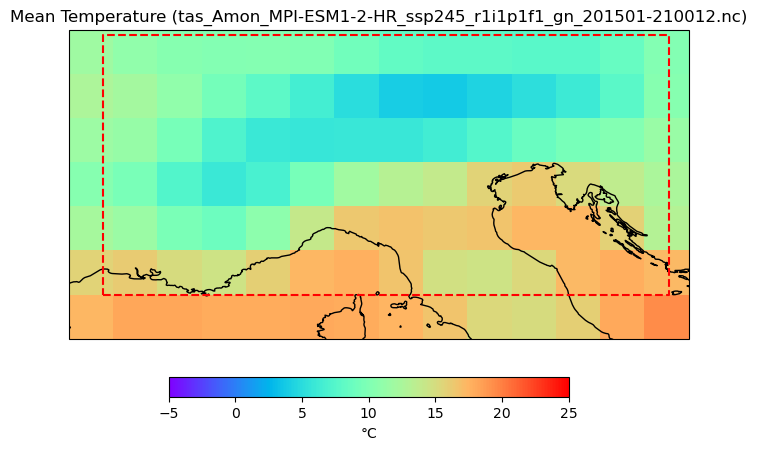

In [10]:
### First plot as a test (mean Temperature)

# Creation figure+axes with projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    longG, latiG, dsGCM.tas.mean("time")[jmin:jmax,imin:imax]-273.15,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
ax.add_feature(cfeature.COASTLINE)
# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
#for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    #ax.plot(glacioClim[i][1],glacioClim[i][2], marker='+',color='black')

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Mean Temperature ({JustFilename})')

In [11]:
years=np.zeros(last_year-first_year+1)
# TTz
T_month = np.zeros(((last_year-first_year+1),12,(jmax-jmin),(imax-imin)))
T_season= np.zeros(((last_year-first_year+1), 4,(jmax-jmin),(imax-imin)))
T_year  = np.zeros(((last_year-first_year+1),   (jmax-jmin),(imax-imin)))

T_month.shape # 4 dimensions : year, month, lat, lon #  (86, 12, 5, 8) ?

(86, 12, 7, 14)

### 2.1 First method 1 : loops ij to reshape the array

In [12]:
# 
y=0
firstMonthOfSeason=np.arange(0, 12, 3, dtype=int)

for year in list(range(first_year,last_year+1)):
#   print(year,y,' ')
    dsyear=dsGCM.tas[:,jmin:jmax,imin:imax].sel(time=f'{year}')-273.15
    #print(dsyear)
    # I nedd to put december before january
    dsyearMod=np.zeros(dsyear.shape)
    #dsyearMod=np.zeros((12,(jmax-jmin),(imax-imin)))
    dsyearMod[0]=dsyear[11]
    dsyearMod[1:12]=dsyear[0:11]
    #print(dsyearMod,'\n')
    years[year-first_year]=year
    T_month[y]=dsyear
    for s in (range(4)):
        m=firstMonthOfSeason[s]
        #print(s,'--------')
        #print(y,s,i,j,dsyearMod[s:s+3,0,0])
        for j in range(0,jmax-jmin):     # 75-70 = 5 should be lat
            for i in range(0,imax-imin): # 10- 2 = 8 should be lon
                
                T_season[y,s,j,i]=np.mean(dsyearMod[s:s+3,j,i]) # year, season, lon=8,lat=5
    y=y+1   
#dsyear 
T_month.shape

(86, 12, 7, 14)

In [13]:
dsGCM

<xarray.Dataset> Size: 304MB
Dimensions:    (time: 1032, bnds: 2, lat: 192, lon: 384)
Coordinates:
  * time       (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T1...
  * lat        (lat) float64 2kB -89.28 -88.36 -87.42 ... 87.42 88.36 89.28
  * lon        (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 17kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 6kB ...
    tas        (time, lat, lon) float32 304MB 244.7 244.7 244.7 ... 262.4 262.4
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    contact:                cmip6-mpi-esm@dkrz.de
    ...                     ...
    variable_id:            tas
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by DKRZ is licensed und...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/5d919613-fddc-429a-a6eb-e7b4cb90eaeb
    NCO:                    netCDF Operators version 4.9.1 (Homepage = http:/...

In [14]:
print(dsyear[0:3,1,1].values)
print(dsyearMod[0:3,1,1])
print(dsGCM.tas[0:3,jmin,imin]-273.15)

[ 7.7323914  9.7864685 13.305328 ]
[10.50784302  7.73239136  9.78646851]
<xarray.DataArray 'tas' (time: 3)> Size: 12B
array([ 9.891998, 11.159973,  9.738953], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 24B 2015-01-16T12:00:00 ... 2015-03-16T12:...
    lat      float64 8B 42.55
    lon      float64 8B 3.75
    height   float64 8B ...


In [15]:
#T_month[0,0]
#years

In [16]:
# T_month[0,0] is the 1rst year 1rst month
# Here we calculate the annual mean
T_annual = np.zeros((jmax-jmin,imax-imin))#((5,8))#((jmax-jmin),(imax-imin))


for j in range(0,jmax-jmin):
    #print()
    for i in range(0,imax-imin):
        #print(i,j,T_month[0,0,i,j],np.mean(T_month[0,:,i,j]))
        T_annual[j,i]=np.mean(T_month[0,:,j,i])
T_annual.shape

(7, 14)

In [17]:
#T_annual

Text(0.5, 1.0, 'Mean Annual Temperature (2015)')

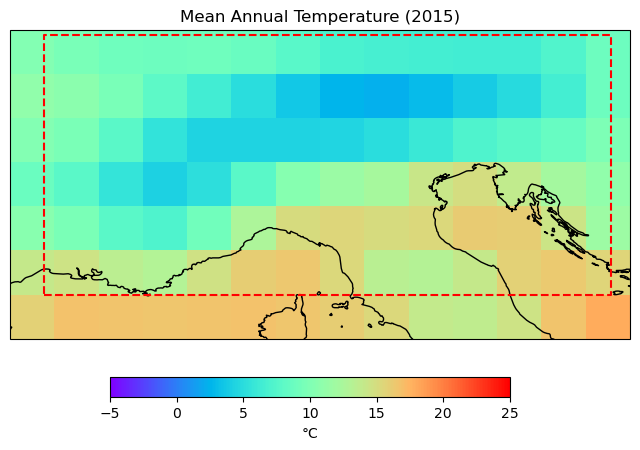

In [18]:
# This figure must be identical to the previous
# to check how data is sorted in Array T_month 

# Creation figure+axes with projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    longG, latiG, T_annual,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
ax.add_feature(cfeature.COASTLINE)
# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
#for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    #ax.plot(glacioClim[i][1],glacioClim[i][2], marker='+',color='black')

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Mean Annual Temperature ({first_year})')

Text(0.5, 1.0, 'Season 0 Mean Temperature (2015) Method 1')

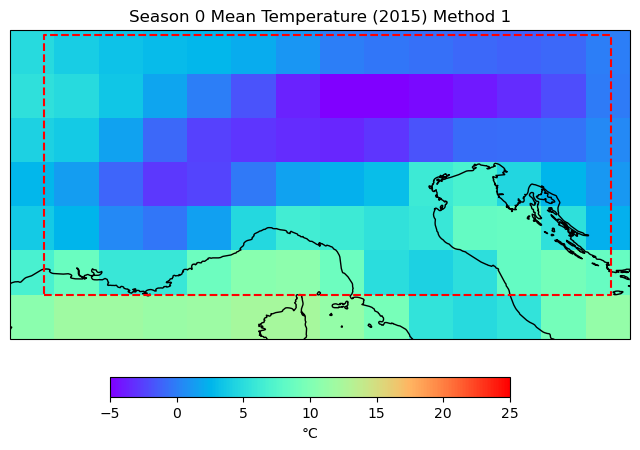

In [19]:
# Creation figure+axes with projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    longG, latiG, T_season[0,0],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
ax.add_feature(cfeature.COASTLINE)
# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
#for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    #ax.plot(glacioClim[i][1],glacioClim[i][2], marker='+',color='black')

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Season 0 Mean Temperature ({first_year}) Method 1')

### 2.2 2nd method with xarray

In [20]:
T_season2= np.zeros(((last_year-first_year+1), 4,(jmax-jmin),(imax-imin)))
T_season2[:,0] = dsGCM.tas[:,jmin:jmax,imin:imax].sel(time=dsGCM.tas.time.dt.season=="DJF").groupby("time.year").mean("time") - 273.16
T_season2[:,1] = dsGCM.tas[:,jmin:jmax,imin:imax].sel(time=dsGCM.tas.time.dt.season=="MAM").groupby("time.year").mean("time") - 273.16
T_season2[:,2] = dsGCM.tas[:,jmin:jmax,imin:imax].sel(time=dsGCM.tas.time.dt.season=="JJA").groupby("time.year").mean("time") - 273.16
T_season2[:,3] = dsGCM.tas[:,jmin:jmax,imin:imax].sel(time=dsGCM.tas.time.dt.season=="SON").groupby("time.year").mean("time") - 273.16
#DJF_tas_MPI245

In [21]:
T_year2= np.zeros(((last_year-first_year+1),(jmax-jmin),(imax-imin)))
T_year2[:] = dsGCM.tas[:,jmin:jmax,imin:imax].groupby("time.year").mean("time") - 273.16

Text(0.5, 1.0, 'Season 0 Mean Temperature (2015) Method 2')

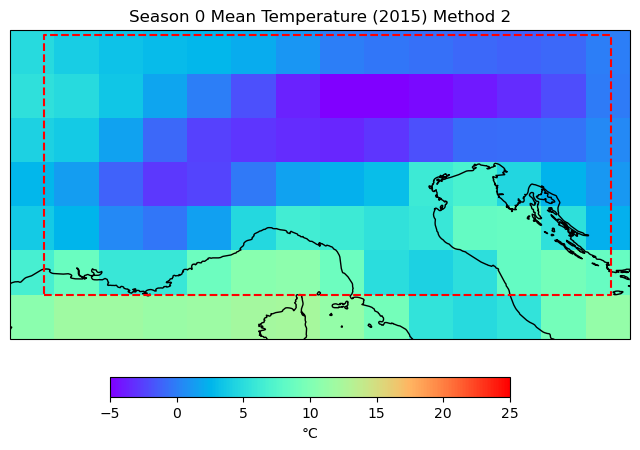

In [22]:
# Creation figure+axes with projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    longG, latiG, T_season2[0,0], #T_season[0,0]-273.15,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
ax.add_feature(cfeature.COASTLINE)
# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
#for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    #ax.plot(glacioClim[i][1],glacioClim[i][2], marker='+',color='black')

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Season 0 Mean Temperature ({first_year}) Method 2')

### 2.3 check if the different methods give the same result (seasonnal)

In [23]:
import matplotlib.colors as mcolors
# Color scale for the notebook
#cmap, quality = plt.get_cmap('rainbow'), 100 
colo_scale = 'rainbow'
vmin_scale, vmax_scale = -5., 25.
# Define a custom normalization for temperature range (optional)
norm = mcolors.Normalize(vmin=-5, vmax=25)
# Proj
proj = ccrs.PlateCarree()
quality = 100

Text(0.5, 0.98, 'Mean seasonal temperature by 2 methods (MPI SSP245)')

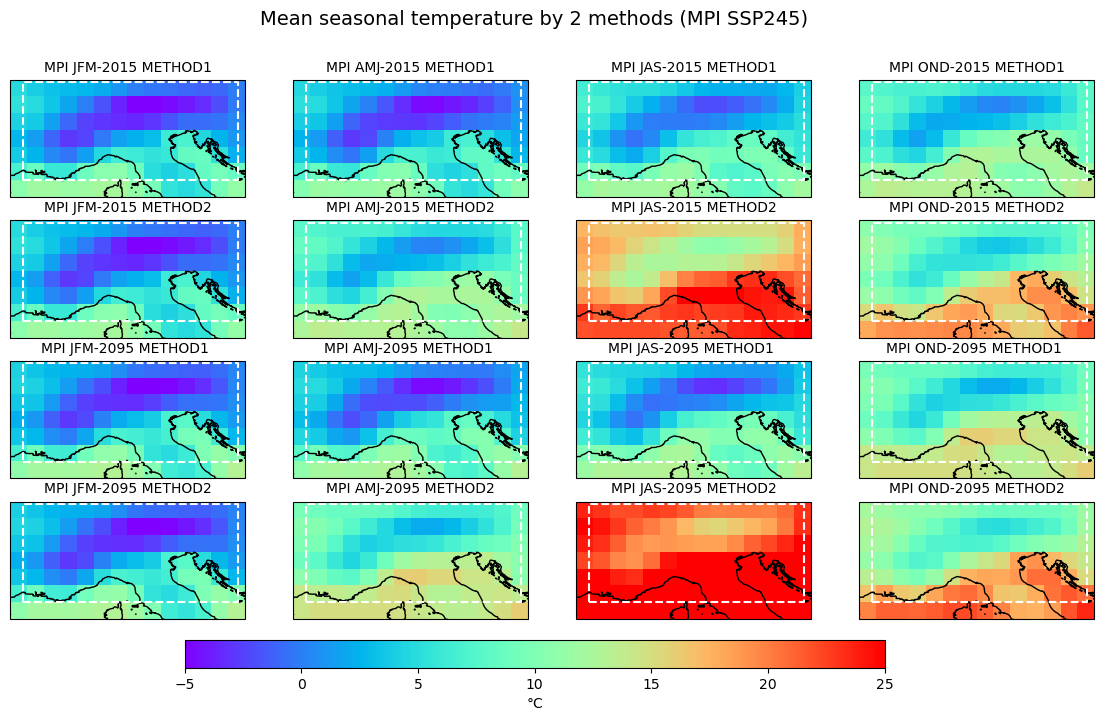

In [24]:
y1, y2 = 0, 80
# Plot temperature pour 4 glacier
projection=ccrs.PlateCarree()
fig, axs = plt.subplots(4, 4, figsize=(14, 7),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
#axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

saisons=['JFM','AMJ','JAS','OND']
             
for i in range(len(saisons)):
    #print(i,saisons[i])
    # ----- GCM METHOD1 Firt year -----
    ax = axs[0, i]
    ax.set_title(f"MPI {saisons[i]}-{y1+2015} METHOD1",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, T_season[y1,i],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    # ----- GCM METHOD2 Firt year -----
    ax = axs[1, i]
    ax.set_title(f"MPI {saisons[i]}-{y1+2015} METHOD2",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, T_season2[y1,i],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    
    # ----- GCM METHOD1 Later -----
    ax = axs[2, i]
    ax.set_title(f"MPI {saisons[i]}-{y2+2015} METHOD1 ",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, T_season[y2,i],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    # ----- GCM METHOD2 Later -----
    ax = axs[3, i]
    ax.set_title(f"MPI {saisons[i]}-{y2+2015} METHOD2",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, T_season2[y2,i],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    
# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.04, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')

fig.suptitle("Mean seasonal temperature by 2 methods (MPI SSP245)", fontsize=14)

In [25]:
print(dsyear[0:3,1,1].values)
print(dsyearMod[0:3,1,1])
print(dsGCM.tas[0:3,jmin,imin])

[ 7.7323914  9.7864685 13.305328 ]
[10.50784302  7.73239136  9.78646851]
<xarray.DataArray 'tas' (time: 3)> Size: 12B
array([283.042  , 284.30997, 282.88895], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 24B 2015-01-16T12:00:00 ... 2015-03-16T12:...
    lat      float64 8B 42.55
    lon      float64 8B 3.75
    height   float64 8B ...
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    comment:        near-surface (usually, 2 meter) air temperature
    units:          K
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2019-07-15T20:20:00Z altered by CMOR: Treated scalar dime...


In [26]:
print("Method 1, i=1, j=1")
print(T_season[y1,0:3,1,1])
print("Method 2, i=1, j=1")
print(T_season2[y1,0:3,1,1])

Method 1, i=1, j=1
[ 8.75476074  8.74606323 10.07393392]
Method 2, i=1, j=1
[ 8.74475098 11.68887329 21.0932312 ]


### 2.3 check if the different methods give the same result (annual)

In [27]:
print(T_year2.shape)

(86, 7, 14)


Text(0.5, 0.98, 'Mean annnual temperature by 2 methods (MPI SSP245)')

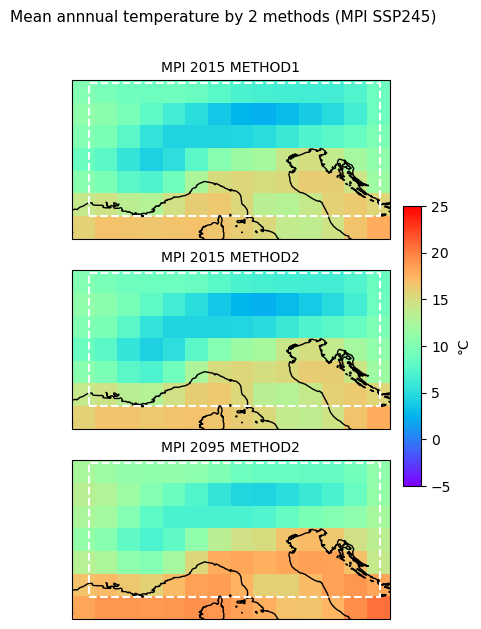

In [28]:
y1, y2 = 0, 80

projection=ccrs.PlateCarree()
fig, axs = plt.subplots(3, figsize=(6, 7),subplot_kw={'projection': proj},dpi=quality)


ax = axs[0]
ax.set_title(f"MPI 2015 METHOD1",fontsize=10)
# pcolormesh
m = ax.pcolormesh(
    longG, latiG, T_annual,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
ax.add_feature(cfeature.COASTLINE)
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
# ----- GCM METHOD2 Firt year -----
ax = axs[1]
ax.set_title(f"MPI {y1+2015} METHOD2",fontsize=10)
# pcolormesh
m = ax.pcolormesh(
longG, latiG, T_year2[y1],
cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
ax.add_feature(cfeature.COASTLINE)
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
# ----- GCM METHOD2 Later -----
ax = axs[2]
ax.set_title(f"MPI {y2+2015} METHOD2",fontsize=10)
# pcolormesh
m = ax.pcolormesh(
longG, latiG, T_year2[y2],
cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
ax.add_feature(cfeature.COASTLINE)
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())

# Vertical colorbar
cbar_ax = fig.add_axes([0.8, 0.3, 0.03, 0.4])
fig.colorbar(m, cax=cbar_ax, orientation='vertical', label='°C')

fig.suptitle("Mean annnual temperature by 2 methods (MPI SSP245)", fontsize=11)

In [29]:
i,j = 4,3
print(f"Method 1, 2015 (point {i},{j}):",T_annual[i,j] )
print(f"Method 2, 2015 (point {i},{j}):",T_year2[0,i,j] )
i,j = 6,10
print(f"Method 1, 2015 (point {i},{j}):",T_annual[i,j] )
print(f"Method 2, 2015 (point {i},{j}):",T_year2[0,i,j] )

Method 1, 2015 (point 4,3): 5.527984619140625
Method 2, 2015 (point 4,3): 5.517974853515625
Method 1, 2015 (point 6,10): 6.441558837890625
Method 2, 2015 (point 6,10): 6.431549072265625


#### method 2 seems OK, pb with method 1 => Save Array T_season2

In [30]:
filout = 'numpyData/tas_'+name_GCM+'_'+scenario
np.savez(filout,T_month=T_month,T_season=T_season2,T_year=T_year2,lon=longG,lat=latiG,years=years)
print(years)
print(filout)

[2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022. 2023. 2024. 2025. 2026.
 2027. 2028. 2029. 2030. 2031. 2032. 2033. 2034. 2035. 2036. 2037. 2038.
 2039. 2040. 2041. 2042. 2043. 2044. 2045. 2046. 2047. 2048. 2049. 2050.
 2051. 2052. 2053. 2054. 2055. 2056. 2057. 2058. 2059. 2060. 2061. 2062.
 2063. 2064. 2065. 2066. 2067. 2068. 2069. 2070. 2071. 2072. 2073. 2074.
 2075. 2076. 2077. 2078. 2079. 2080. 2081. 2082. 2083. 2084. 2085. 2086.
 2087. 2088. 2089. 2090. 2091. 2092. 2093. 2094. 2095. 2096. 2097. 2098.
 2099. 2100.]
numpyData/tas_MPI-ESM1-2-HR_ssp245


### 2.5 Save GCM Topo

In [31]:
# Topo GCM
PathTopoG = path_DIR+'GCM/'+dirGCM+'/'
dsTopoG = xr.open_dataset(PathTopoG+'orog_fx_MPI-ESM1-2-HR_historical_r1i1p1f1_gn.nc')

longGT=dsGCM.lon[imin:imax]
latiGT=dsGCM.lat[jmin:jmax]

# Surface Altitude
altiG = dsTopoG.orog[jmin:jmax,imin:imax]

In [32]:
print(longG)
print(longGT)

<xarray.DataArray 'lon' (lon: 14)> Size: 112B
array([ 3.75  ,  4.6875,  5.625 ,  6.5625,  7.5   ,  8.4375,  9.375 , 10.3125,
       11.25  , 12.1875, 13.125 , 14.0625, 15.    , 15.9375])
Coordinates:
  * lon      (lon) float64 112B 3.75 4.688 5.625 6.562 ... 14.06 15.0 15.94
    height   float64 8B ...
Attributes:
    bounds:         lon_bnds
    units:          degrees_east
    axis:           X
    long_name:      Longitude
    standard_name:  longitude
<xarray.DataArray 'lon' (lon: 14)> Size: 112B
array([ 3.75  ,  4.6875,  5.625 ,  6.5625,  7.5   ,  8.4375,  9.375 , 10.3125,
       11.25  , 12.1875, 13.125 , 14.0625, 15.    , 15.9375])
Coordinates:
  * lon      (lon) float64 112B 3.75 4.688 5.625 6.562 ... 14.06 15.0 15.94
    height   float64 8B ...
Attributes:
    bounds:         lon_bnds
    units:          degrees_east
    axis:           X
    long_name:      Longitude
    standard_name:  longitude


In [33]:
filout = 'numpyData/topo_GCM_MPI_SurfaceH'
np.savez(filout,SH=altiG)
print(filout)

numpyData/topo_GCM_MPI_SurfaceH


## 3. Save MAR MPI

In [34]:
name_GCM = shortnameGCM
scenario = 'SSP245' #'HIST' #'SSP245' #'SSP585' # MAR
# Information on the first file
year=first_year
#file1=path_MAR+'/'+scenario+'/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_'+scenario+'.'+sim+'.TTz.'+str(year)+'.nc'

file1=path_MARSIMU+'/'+scenario+'/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_'+scenario+'.'+simSSP+'.TTz.'+str(year)+'.nc'
#file1='/bettik/peyaudv/MAR_GCMs/GCM/EC-Earth3/tas_Amon_EC-Earth3_ssp245_r1i1p1f1_gr_201501-201512_EU.nc '
print(file1)
ds = xr.open_dataset(file1) # Alternative #ds = xr.open_dataset(os.path.join(path,file))
#ds

/Users/peyaudv/Glaciers/MAR_GCMs/MARout//MAR-MPI-ESM1-2-HR//SSP245/monthly/MON.MPI-ESM_SSP245.EUv.TTz.2015.nc


In [35]:
# Topo MAR
dsTopo = xr.open_dataset(path_MAR+'MAR-ERA-20C/MARgrid_EUf.nc')

iminM = 32 ; imaxM = -30
jminM = 20 ; jmaxM = -15
longM = dsTopo.LON[jminM:jmaxM,iminM:imaxM]
latiM = dsTopo.LAT[jminM:jmaxM,iminM:imaxM]

# Surface Altitude
altiM = dsTopo.SH[jminM:jmaxM,iminM:imaxM]

In [36]:
#dsTopo.LON[jmin:jmax,0]

In [37]:
dsTopo.LON.shape

(126, 201)

In [38]:
dsTopo.LON[jminM:jmaxM,iminM:imaxM].shape

(91, 139)

In [39]:
longM.shape

(91, 139)

Text(0.5, 1.0, 'Mean Temperature (MON.MPI-ESM_SSP245.EUv.TTz.2015.nc)')

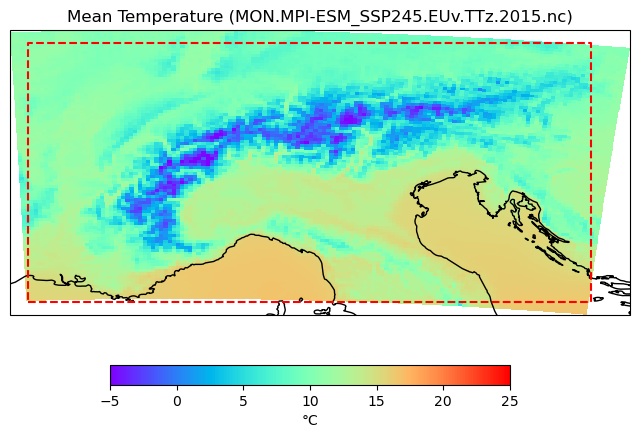

In [40]:
# Creation figure+axes with projection PlateCarree (cyl)
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
m = ax.pcolormesh(
    longM, latiM, ds.TTz.mean("time")[0,jminM:jmaxM,iminM:imaxM],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
ax.add_feature(cfeature.COASTLINE)
# Tracé du polygone en pointillés rouge
ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

# Position des glaciers
#for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    #ax.plot(glacioClim[i][1],glacioClim[i][2], marker='+',color='black')

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')

JustFilename = file1.rsplit('/', 1)[-1] # split at / ; filename is the last occurence
ax.set_title(f'Mean Temperature ({JustFilename})')

In [41]:
years=np.zeros(last_year-first_year+1)
# TTz
T_month = np.zeros(((last_year-first_year+1),12,91,139))
T_season= np.zeros(((last_year-first_year+1), 4,91,139))
T_year  = np.zeros(((last_year-first_year+1)   ,91,139))
# 4 dimensions : year, month, AND lon, lat ???  
T_month.shape

(86, 12, 91, 139)

In [42]:
name_GCM=shortnameGCM
# Open files and copy data in Arrays T_month and T_season (for months and saisons data)
for year in list(range(first_year,last_year+1)):
    print(year,end=' ')
    #if year == 1985 or year == 2071:
    #    continue
       # file1=path_MARSIMU+'/'+scenario+'/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_'+scenario+'.'+sim+'.TTz.'+str(year)+'.nc'
    hist_path = path_MARSIMU+'/HIST/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_HIST.'+simHIST+'.TTz.'+str(year)+'.nc'
    ssp245_path = path_MARSIMU+'/SSP245/'+data_freq+'/'+data_freq_prefix+'.'+name_GCM+'_SSP245.'+simSSP+'.TTz.'+str(year)+'.nc'
    if year <2015:
        ds_var = xr.open_dataset(hist_path)
    else:
        #ds_T = xr.open_dataset('/bettik/beaumetj/MARout/MAR-EC-Earth3/SSP245/monthly/MON.EC-Earth3_SSP245.EUe.TTz.'+str(year)+'.nc')
        ds_var = xr.open_dataset(ssp245_path)
        #print("ssp245_path")
    T_month[year-first_year]=ds_var.TTz.isel(ztqlev=0)[:,jminM:jmaxM,iminM:imaxM]
    T_season[year-first_year]=season_mean(ds_var.TTz.sel(ztqlev=2)).sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))[:,jminM:jmaxM,iminM:imaxM]
    T_year[year-first_year]=ds_var.TTz.isel(ztqlev=0)[:,jminM:jmaxM,iminM:imaxM].mean("time")
    
    seasonal_mean_year=season_mean(ds_var.TTz.sel(ztqlev=2)).sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))
    years[year-first_year]=year
    
   # T_year2[:] = dsGCM.tas[:,jmin:jmax,imin:imax].groupby("time.year").mean("time") - 273.16

2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045 2046 2047 2048 2049 2050 2051 2052 2053 2054 2055 2056 2057 2058 2059 2060 2061 2062 2063 2064 2065 2066 2067 2068 2069 2070 2071 2072 2073 2074 2075 2076 2077 2078 2079 2080 2081 2082 2083 2084 2085 2086 2087 2088 2089 2090 2091 2092 2093 2094 2095 2096 2097 2098 2099 2100 

In [43]:
filout = 'numpyData/ttz_'+'MAR'+name_GCM+'_'+scenario
np.savez(filout,T_month=T_month,T_season=T_season,T_year=T_year,lon=longM,lat=latiM,years=years)
print(filout)

numpyData/ttz_MARMPI-ESM_SSP245


### 3.2 Save MAR Topo

In [44]:
filout = 'numpyData/topo_MAR_SurfaceH'
np.savez(filout,SH=altiM)
print(filout)

numpyData/topo_MAR_SurfaceH


# 5. Save GCM Topo

In [45]:
dsTopoG

<xarray.Dataset> Size: 309kB
Dimensions:   (lat: 192, bnds: 2, lon: 384)
Coordinates:
  * lat       (lat) float64 2kB -89.28 -88.36 -87.42 ... 87.42 88.36 89.28
  * lon       (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
Dimensions without coordinates: bnds
Data variables:
    lat_bnds  (lat, bnds) float64 3kB ...
    lon_bnds  (lon, bnds) float64 6kB ...
    orog      (lat, lon) float32 295kB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    contact:                cmip6-mpi-esm@dkrz.de
    ...                     ...
    title:                  MPI-ESM1-2-HR output prepared for CMIP6
    tracking_id:            hdl:21.14100/3341d289-1282-489f-9419-c263718da247
    variable_id:            orog
    variant_label:          r1i1p1f1
    license:                CMIP6 model data produced by MPI-M is licensed un...
    cmor_version:           3.5.0